<a href="https://colab.research.google.com/github/oluchiokoro-debug/colab-git-assignment2-OO/blob/main/Titanic_Survival_Classification_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load dataset
df = pd.read_csv("/content/sample_data/mnist_train_small.csv")

# Display first 5 rows
df.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (19999, 785)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Columns: 785 entries, 6 to 0.590
dtypes: int64(785)
memory usage: 119.8 MB

Missing Values:
6        0
0        0
0.1      0
0.2      0
0.3      0
        ..
0.586    0
0.587    0
0.588    0
0.589    0
0.590    0
Length: 785, dtype: int64

Summary Statistics:
                  6        0      0.1      0.2      0.3      0.4      0.5  \
count  19999.000000  19999.0  19999.0  19999.0  19999.0  19999.0  19999.0   
mean       4.470124      0.0      0.0      0.0      0.0      0.0      0.0   
std        2.892807      0.0      0.0      0.0      0.0      0.0      0.0   
min        0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
25%        2.000000      0.0      0.0      0.0      0.0      0.0      0.0   
50%        4.000000      0.0      0.0      0.0      0.0      0.0      0.0   
75%        7.000000      0.0      0.0      0.0      0.0      0.0      0.0  

In [5]:
df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

New Shape: (19999, 785)


In [7]:
print(df.isnull().sum())

6        0
0        0
0.1      0
0.2      0
0.3      0
        ..
0.586    0
0.587    0
0.588    0
0.589    0
0.590    0
Length: 785, dtype: int64


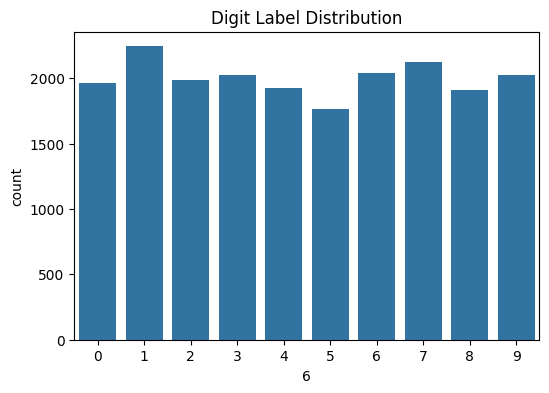

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='6', data=df)
plt.title("Digit Label Distribution")
plt.show()

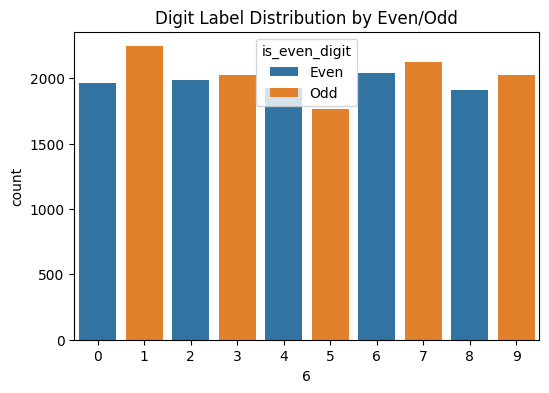

In [11]:
plt.figure(figsize=(6,4))
# Create a temporary categorical column for the hue argument
df['is_even_digit'] = df['6'].apply(lambda x: 'Even' if x % 2 == 0 else 'Odd')
sns.countplot(x='6', hue='is_even_digit', data=df)
plt.title("Digit Label Distribution by Even/Odd")
plt.show()

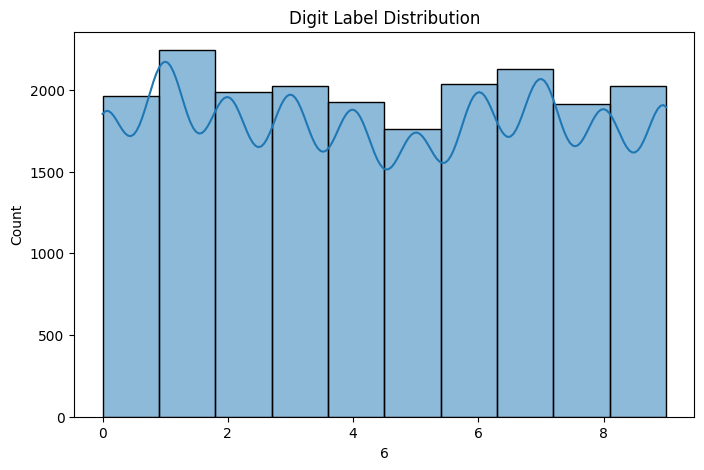

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['6'], bins=10, kde=True)
plt.title("Digit Label Distribution")
plt.show()

In [15]:
le = LabelEncoder()

# The original 'Sex' and 'Embarked' columns do not exist in the MNIST dataset.
# LabelEncoder is not applicable to this numerical dataset.

In [34]:
df.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590,is_even_digit
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Odd
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Odd
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Odd
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Odd
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Even


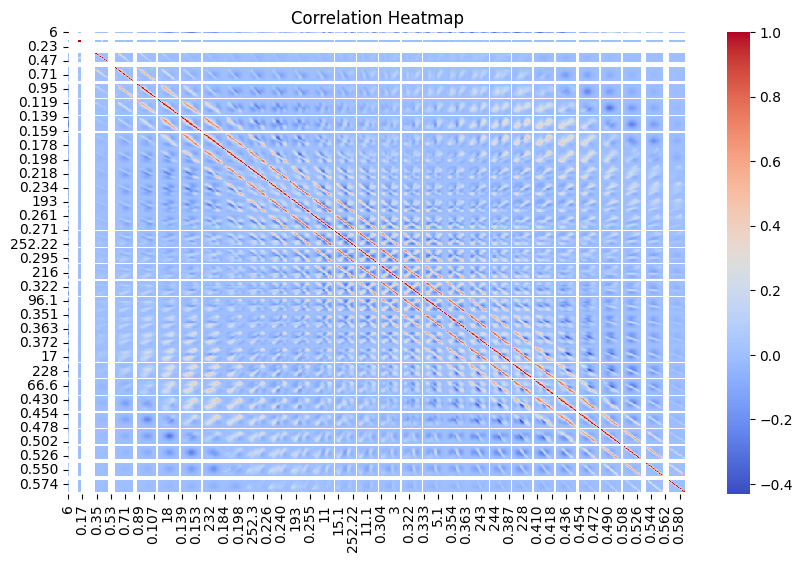

In [35]:
plt.figure(figsize=(10,6))
# Drop non-numeric columns for correlation calculation
numeric_df = df.drop(columns=['is_even_digit'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm') # annot=False for better visibility with many columns
plt.title("Correlation Heatmap")
plt.show()

In [19]:
X = df.drop(columns=['6', 'is_even_digit'])
y = df['6']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (15999, 784)
Testing Shape: (4000, 784)


In [20]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_prob = lr_model.predict_proba(X_test)[:,1]

In [22]:
print("LOGISTIC REGRESSION RESULTS")

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, average='weighted'))
print("Recall:", recall_score(y_test, lr_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, lr_pred, average='weighted'))

# Recompute lr_prob for multiclass ROC AUC as the original lr_prob was 1D
lr_prob_multiclass = lr_model.predict_proba(X_test)
print("ROC-AUC:", roc_auc_score(y_test, lr_prob_multiclass, multi_class='ovr', average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8965
Precision: 0.8965267983965494
Recall: 0.8965
F1 Score: 0.8963571108842625
ROC-AUC: 0.9897295968374572

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       377
           1       0.95      0.97      0.96       436
           2       0.86      0.88      0.87       390
           3       0.87      0.89      0.88       406
           4       0.89      0.91      0.90       401
           5       0.83      0.84      0.84       341
           6       0.94      0.92      0.93       412
           7       0.92      0.92      0.92       438
           8       0.86      0.80      0.83       384
           9       0.87      0.87      0.87       415

    accuracy                           0.90      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.90      0.90      0.90      4000



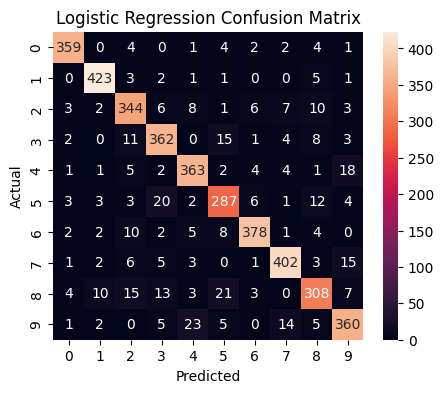

In [23]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [26]:
print("RANDOM FOREST RESULTS")

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average='weighted'))
print("Recall:", recall_score(y_test, rf_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, rf_pred, average='weighted'))

# Recompute rf_prob for multiclass ROC AUC
rf_prob_multiclass = rf_model.predict_proba(X_test)
print("ROC-AUC:", roc_auc_score(y_test, rf_prob_multiclass, multi_class='ovr', average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

RANDOM FOREST RESULTS
Accuracy: 0.954
Precision: 0.9541646751212319
Recall: 0.954
F1 Score: 0.9539695820197219
ROC-AUC: 0.997697573054826

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       377
           1       0.97      0.98      0.97       436
           2       0.93      0.95      0.94       390
           3       0.96      0.95      0.95       406
           4       0.93      0.96      0.94       401
           5       0.97      0.95      0.96       341
           6       0.97      0.96      0.97       412
           7       0.96      0.94      0.95       438
           8       0.95      0.95      0.95       384
           9       0.94      0.92      0.93       415

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000



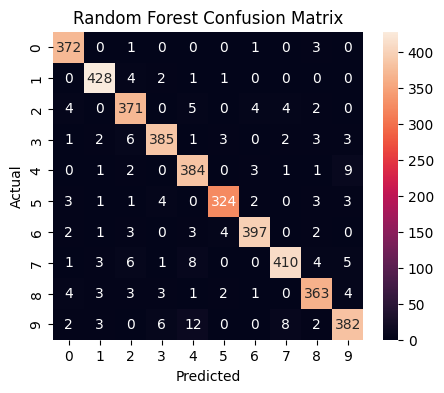

In [27]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

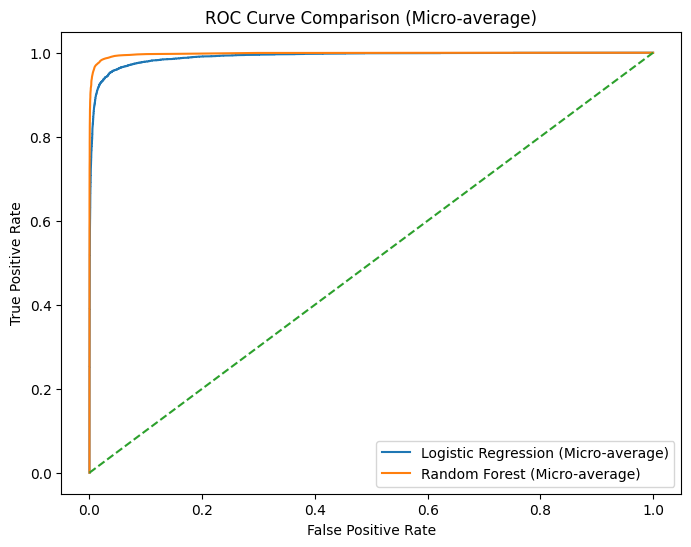

In [29]:
from sklearn.preprocessing import label_binarize

# Binarize y_test for micro-average ROC curve
y_test_binarized = label_binarize(y_test, classes=lr_model.classes_)

# Use the multiclass probabilities calculated previously
# lr_prob_multiclass = lr_model.predict_proba(X_test)
# rf_prob_multiclass = rf_model.predict_proba(X_test)

# Calculate micro-average ROC curve for Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test_binarized.ravel(), lr_prob_multiclass.ravel())

# Calculate micro-average ROC curve for Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test_binarized.ravel(), rf_prob_multiclass.ravel())

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label='Logistic Regression (Micro-average)')
plt.plot(rf_fpr, rf_tpr, label='Random Forest (Micro-average)')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Micro-average)')
plt.legend()
plt.show()

In [31]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred, average='weighted'),
        precision_score(y_test, rf_pred, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, lr_pred, average='weighted'),
        recall_score(y_test, rf_pred, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred, average='weighted'),
        f1_score(y_test, rf_pred, average='weighted')
    ]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.8965   0.896527  0.8965  0.896357
1        Random Forest    0.9540   0.954165  0.9540  0.953970


In [32]:
best_model = results.loc[results['Accuracy'].idxmax()]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Random Forest
Accuracy             0.954
Precision         0.954165
Recall               0.954
F1 Score           0.95397
Name: 1, dtype: object
